<h2 style="text-align: center;"> CALIFORNIA HOUSING PRICES </h2>

<img src="img/ITQ.jpg" width="700">

**Fecha:** *4/6/2026* <br>
**Nombre:** *Sebastian Sampedro* <br>
**Link Github:** "https://github.com/sdsampedro-byte/Python2026ML"

In [1]:
#Importacion de librerias 
import pandas as pd
import numpy as np
#from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
# Librerias de regresión lineal
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler

import zipfile

In [2]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/Sebas/.kaggle"

In [3]:
#Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [4]:
#Descargamos el dataset - Usuario/Nombre del conjunto de datos
!kaggle datasets download -d camnugent/california-housing-prices

Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0
california-housing-prices.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
#Descompriminos el archivo 
with zipfile.ZipFile("california-housing-prices.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [6]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset/housing.csv")

In [7]:
# Mostramos el conjunto de datos
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [8]:
#Mostramos los detalles de nuesto dataset
df.info()
#Verificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [9]:
# Calculamos la media de la columna total_bedrooms
mediana_bedrooms = df['total_bedrooms'].median()

# Rellenamos los datos nulos con la media calculada
df['total_bedrooms'] = df['total_bedrooms'].fillna(mediana_bedrooms)

In [10]:
# Verificamos que ya no existan valores nulos
df['total_bedrooms'].isnull().sum()

np.int64(0)

In [11]:
#Mostramos los detalles de nuesto dataset
df.info()
#Verificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### ANTES en 'Total_bedrooms = 20433' y AHORA con la limpieza de datos (rellenar nulos con la media aritmética) 'Total_bedrooms = 20640'

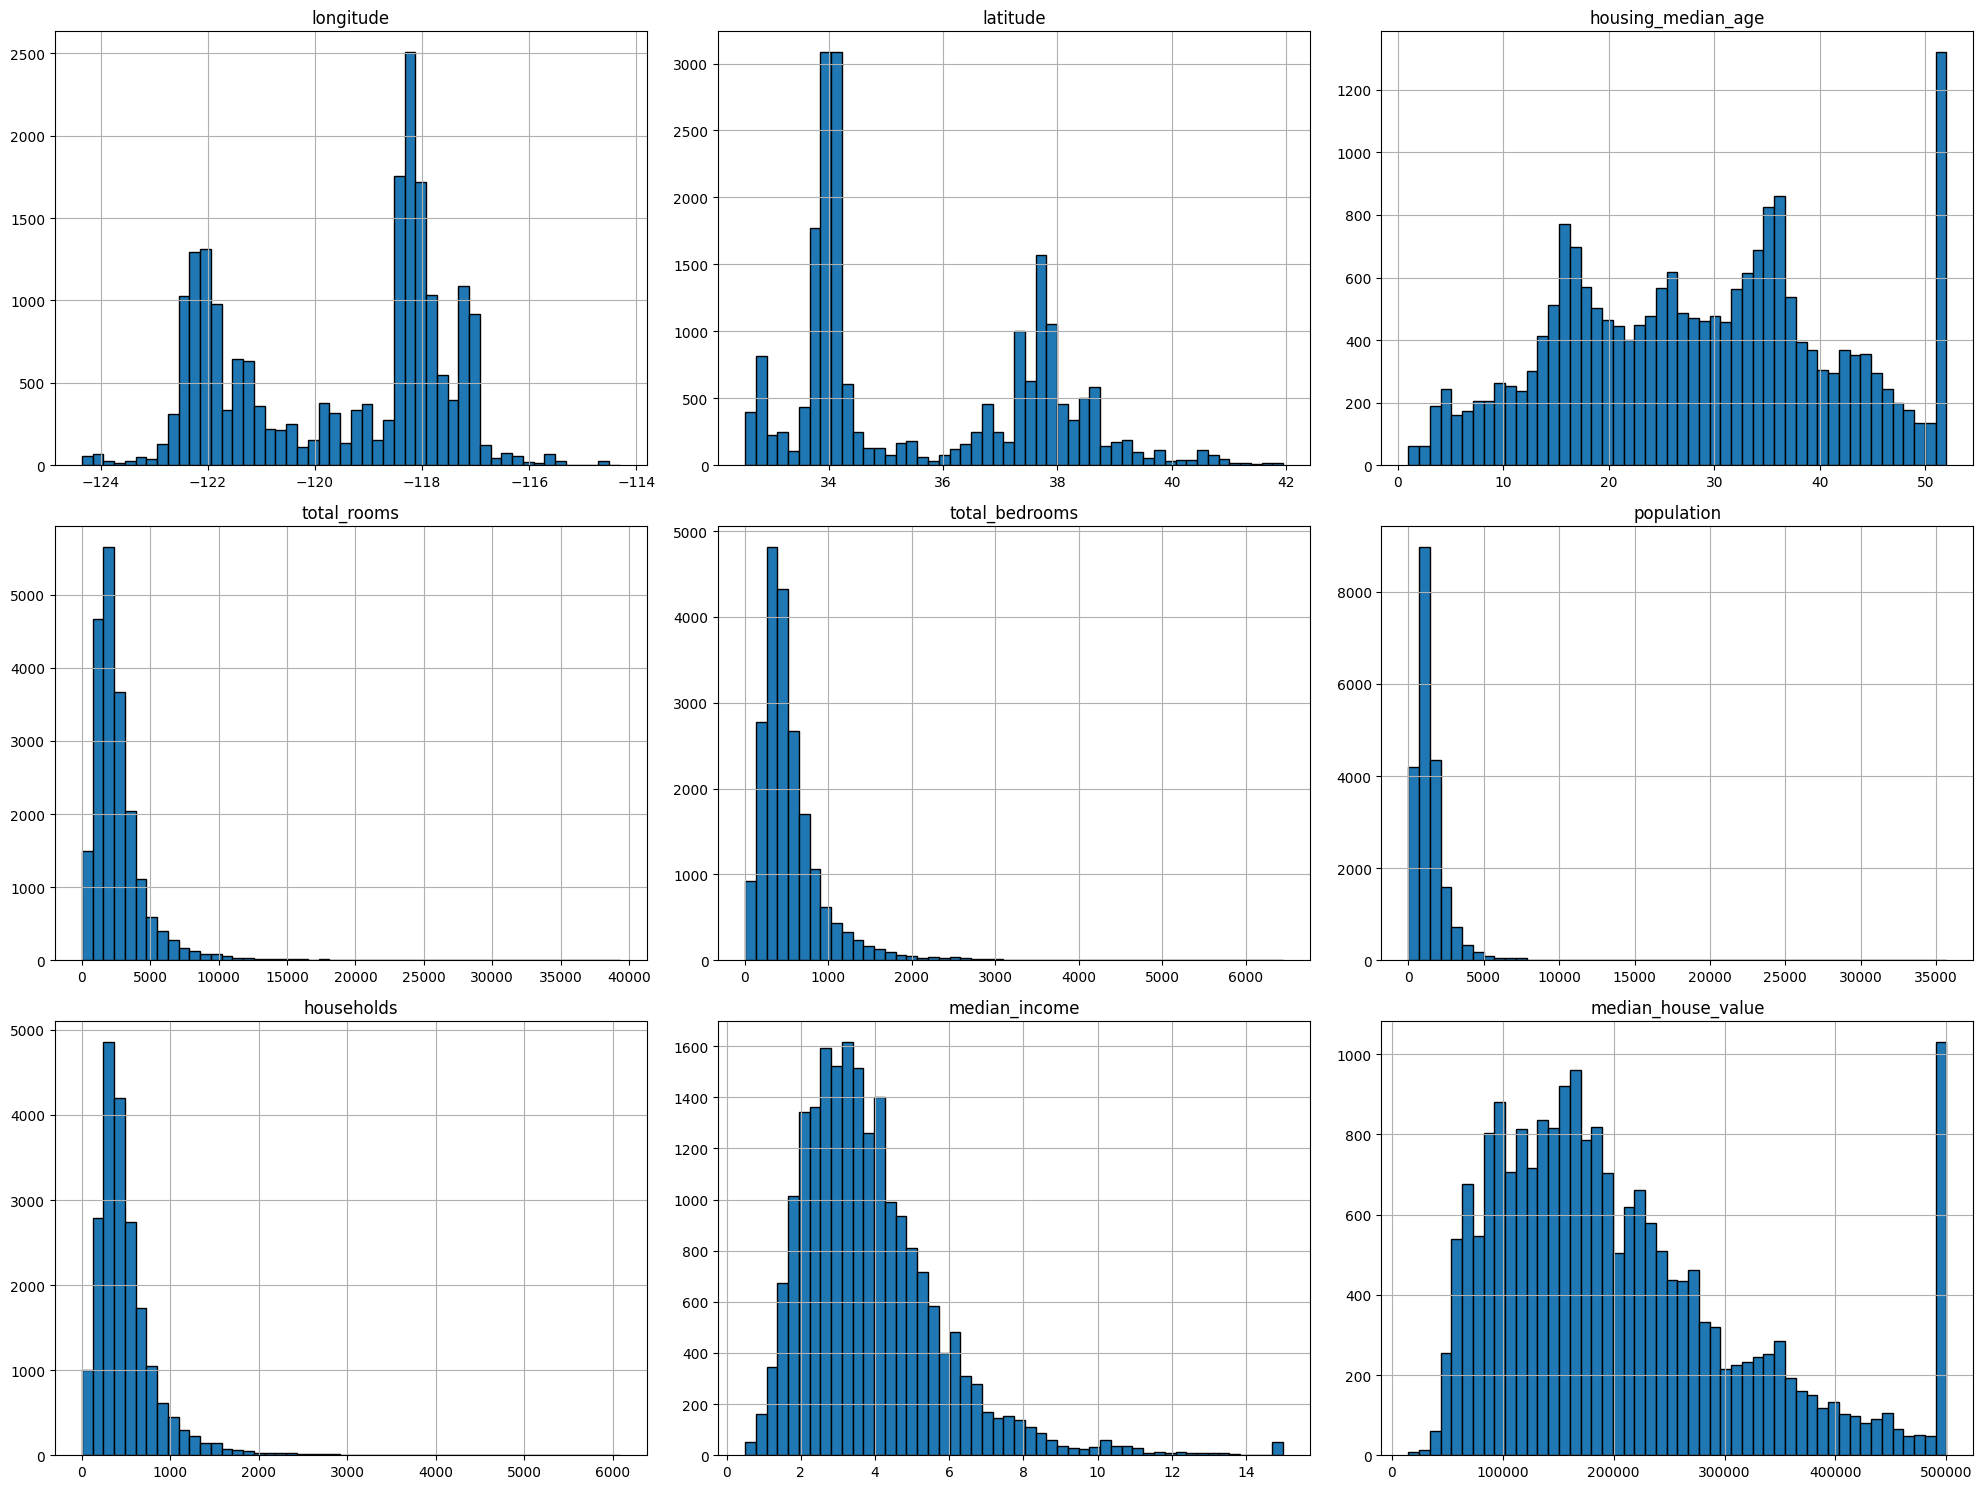

In [12]:
# Configurar el tamaño de la gráfica y generar los histogramas
df.hist(bins=50, figsize=(20, 15), edgecolor='black')

# Ajustar el diseño para que las etiquetas y títulos no se superpongan
plt.tight_layout()

# Guardar la gráfica en un archivo de imagen
plt.savefig('distribucion_variables_numéricas.png', dpi=300)
plt.show()

In [13]:
# Resumen de estadística descriptiva para las variables numéricas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Limpieza de datos

In [14]:
# Eliminación de topes artificiales ('median_house_value < 500000 y 'housing_median_age' < 52)
df_clean = df[(df['median_house_value'] < 500000) & (df['housing_median_age'] < 52.0)].copy()

# Elimiunar valores físicamente imposibles, más dormitorios que habitaciones
df_clean = df_clean[df_clean['total_bedrooms'] <= df_clean['total_rooms']]

In [15]:
# Visualizo el dataset limpio
df_clean.info()

<class 'pandas.DataFrame'>
Index: 18551 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           18551 non-null  float64
 1   latitude            18551 non-null  float64
 2   housing_median_age  18551 non-null  float64
 3   total_rooms         18551 non-null  float64
 4   total_bedrooms      18551 non-null  float64
 5   population          18551 non-null  float64
 6   households          18551 non-null  float64
 7   median_income       18551 non-null  float64
 8   median_house_value  18551 non-null  float64
 9   ocean_proximity     18551 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### Visualización Espacial

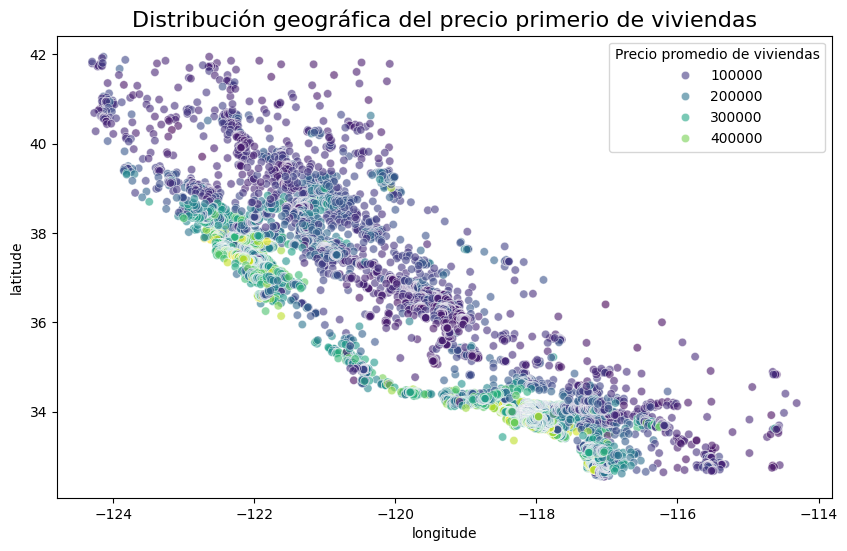

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='median_house_value', palette='viridis', alpha=0.6)
plt.legend(title='Precio promedio de viviendas', loc='upper right')
plt.title('Distribución geográfica del precio primerio de viviendas', fontsize=16)
plt.show()

### Análisis de correlación

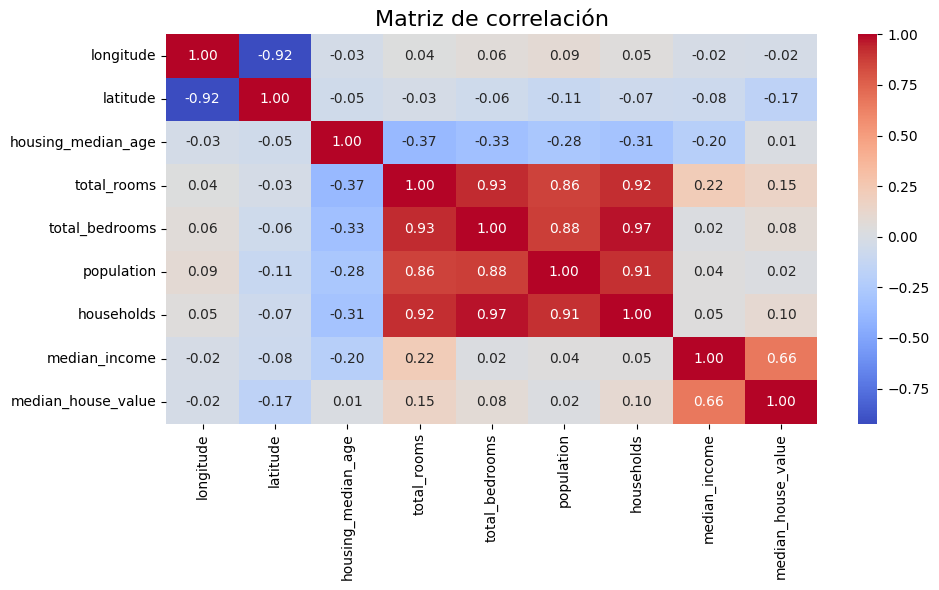

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación', fontsize=16)
plt.tight_layout()
plt.show()

### Ingeniería de características

In [18]:
LA, SF= (34.0522, -118.2437), (37.7749, -122.4194)

# Creación de variables geográficas (Proximidad a centros económicos)
df_clean['dist_to_LA'] = np.sqrt((df_clean['latitude'] - LA[0])**2 + (df_clean['longitude'] - LA [1])**2)
df_clean['dist_to_SF'] = np.sqrt((df_clean['latitude'] - LA[0])**2 + (df_clean['longitude'] - SF [1])**2)

# Ratios
df_clean['bedrooms_per_room'] = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['pop_per_household'] = df_clean['population'] / df_clean['households']

# Encoding de variables categóricas
df_clean = pd.get_dummies(df_clean, columns=['ocean_proximity'], drop_first=True)

### Análisis de Correlación de las nuevas variables

In [19]:
corr_matriz = df_clean.corr()
print("\nCorrelación respecto al precio promedio de viviendas:")
display(corr_matriz['median_house_value'].sort_values(ascending=False))


Correlación respecto al precio promedio de viviendas:


median_house_value            1.000000
median_income                 0.664341
total_rooms                   0.153769
ocean_proximity_NEAR OCEAN    0.147346
ocean_proximity_NEAR BAY      0.111688
households                    0.100436
total_bedrooms                0.079249
population                    0.022399
ocean_proximity_ISLAND        0.019534
housing_median_age            0.014207
pop_per_household            -0.020200
longitude                    -0.022912
dist_to_LA                   -0.143450
latitude                     -0.171567
bedrooms_per_room            -0.227051
dist_to_SF                   -0.302014
ocean_proximity_INLAND       -0.501263
Name: median_house_value, dtype: float64

### Preparación de Datos para el Modelado

In [20]:
# Definir las variables predictoras y la variable objetivo
X = df_clean.drop('median_house_value', axis=1)
y = df_clean['median_house_value']

# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
print(X)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
8        -122.26     37.84                42.0       2555.0           665.0   
15       -122.26     37.85                50.0       1120.0           283.0   
18       -122.26     37.84                50.0       2239.0           455.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  dist_

In [22]:
print(y)

0        452600.0
1        358500.0
8        226700.0
15       140000.0
18       158700.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 18551, dtype: float64


### Modelado y Entrenamiento

In [23]:
# Instanciar y entrenar el modelo de regresion lineal 
linear_model = LinearRegression()
ridge_model = Ridge(alpha=10.0, random_state=42) #alpha es la fuerza de regularización
lasso_model = Lasso(alpha=50, random_state=42, max_iter=10000)

# Entrenamos los módelos de aprendizaje
linear_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)

,alpha,50
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


### Regresión Lineal Estándar

In [24]:
# Predicciones de entrenamiento
y_train_pred_linear = linear_model.predict(X_train_scaled)

# Predicciones Prueba
y_test_pred_linear = linear_model.predict(X_test_scaled)

# Cálculo de RMSE. Fórmula: RMSE: sqrt(mean(y_true - y_pred)^2))
rmse_train_linear = np.sqrt(np.mean((y_train - y_train_pred_linear) ** 2))
rmse_test_linear = np.sqrt(np.mean((y_test - y_test_pred_linear) ** 2))

# Cálculo de MAE
mae_train_linear = np.mean(np.abs(y_train - y_train_pred_linear))
mae_test_linear = np.mean(np.abs(y_test - y_test_pred_linear))

# Mostramos los resultados 
print(f"Linear - RMSE Train: {rmse_train_linear:.2f}")
print(f"Linear - RMSE Test: {rmse_test_linear:.2f}")

print(f"Linear - MAE Train: {rmse_train_linear:.2f}")
print(f"Linear - MAE Test: {rmse_test_linear:.2f}")

# Importancia de variables
coef_linear = pd.DataFrame({'Característica': X.columns, 'Importancia': linear_model.coef_.round(3)})

coef_linear = coef_linear.sort_values(by='Importancia', key=abs, ascending=False)

display(coef_linear.head(10))

Linear - RMSE Train: 57442.48
Linear - RMSE Test: 57372.24
Linear - MAE Train: 57442.48
Linear - MAE Test: 57372.24


,Característica,Importancia
7,median_income,62745.832
0,longitude,-46987.541
5,population,-38207.064
6,households,29510.883
8,dist_to_LA,-25700.735
1,latitude,-22124.710
12,ocean_proximity_INLAND,-17954.744
10,bedrooms_per_room,11574.703
3,total_rooms,6570.599
4,total_bedrooms,5849.883


### Modelo Ridge

In [25]:
# Predicciones
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Cálculo de RMSE. Fórmula: RMSE: sqrt(mean((y_true - y_pred)^2))
rmse_train_ridge = np.sqrt(np.mean((y_train - y_train_pred_ridge) ** 2))
rmse_test_ridge = np.sqrt(np.mean((y_test - y_test_pred_ridge) ** 2))

print(f"Ridge - RMSE Train: {rmse_train_ridge:.2f}")
print(f"Ridge - RMSE Test: {rmse_test_ridge:.2f}")

mae_train_ridge = np.mean(np.abs(y_train - y_train_pred_ridge))
mae_test_ridge = np.mean(np.abs(y_test - y_test_pred_ridge))

print(f"MAE Train: {mae_train_ridge:.2f}")
print(f"MAE Test: {mae_test_ridge:.2f}")

# Ver qué variables tienen coeficientes más grandes en el módelo Ridge
coeficientes = pd.DataFrame({'Característica': X.columns, 'Importancia': ridge_model.coef_.round(3)}).sort_values(by='Importancia', key=abs, ascending=False)
print("\nImportancia de las características según el módelo Ridge:")
display(coeficientes.head(10))

Ridge - RMSE Train: 57443.48
Ridge - RMSE Test: 57365.56
MAE Train: 41991.32
MAE Test: 42285.94

Importancia de las características según el módelo Ridge:


,Característica,Importancia
7,median_income,62711.439
0,longitude,-44700.007
5,population,-37897.362
6,households,29079.955
8,dist_to_LA,-24860.111
1,latitude,-20654.108
12,ocean_proximity_INLAND,-18385.992
10,bedrooms_per_room,11524.084
3,total_rooms,6462.832
4,total_bedrooms,6108.906


### Modelo LASSO (Regularización L1)

In [26]:
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

# Cálculo de RMSE. Fórmula: RMSE: sqrt(mean((y_true - y_pred)^2))
rmse_train_lasso = np.sqrt(np.mean((y_train - y_train_pred_lasso) ** 2))
rmse_test_lasso = np.sqrt(np.mean((y_test - y_test_pred_lasso) ** 2))

print(f"Lasso - RMSE Train: {rmse_train_lasso:.2f}")
print(f"Lasso - RMSE Test: {rmse_test_lasso:.2f}")

mae_train_lasso = np.mean(np.abs(y_train - y_train_pred_lasso))
mae_test_lasso = np.mean(np.abs(y_test - y_test_pred_lasso))

print(f"MAE Train: {mae_train_lasso:.2f}")
print(f"MAE Test: {mae_test_lasso:.2f}")

# Ver qué variables tienen coeficientes más grandes en el modelo Lasso
coeficientes_lasso = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': lasso_model.coef_.round(3)
}).sort_values(by='Importancia', key=abs, ascending=False)

print("\nImportancia de las características según el modelo Lasso:")
display(coeficientes_lasso.head())

# Ver si Lasso ha eliminado alguna variable (coeficiente exactamente 0)
variables_eliminadas = coeficientes_lasso[coeficientes_lasso['Importancia'] == 0]['Característica'].tolist()
print(f"\nVariables eliminadas por Lasso (coeficiente 0): {variables_eliminadas}")

Lasso - RMSE Train: 57446.23
Lasso - RMSE Test: 57363.30
MAE Train: 41990.58
MAE Test: 42287.08

Importancia de las características según el modelo Lasso:


,Característica,Importancia
7,median_income,62752.112
0,longitude,-42713.341
5,population,-37478.358
6,households,29167.016
8,dist_to_LA,-24269.604



Variables eliminadas por Lasso (coeficiente 0): []


### Gráficas Valores Reales VS Predichos

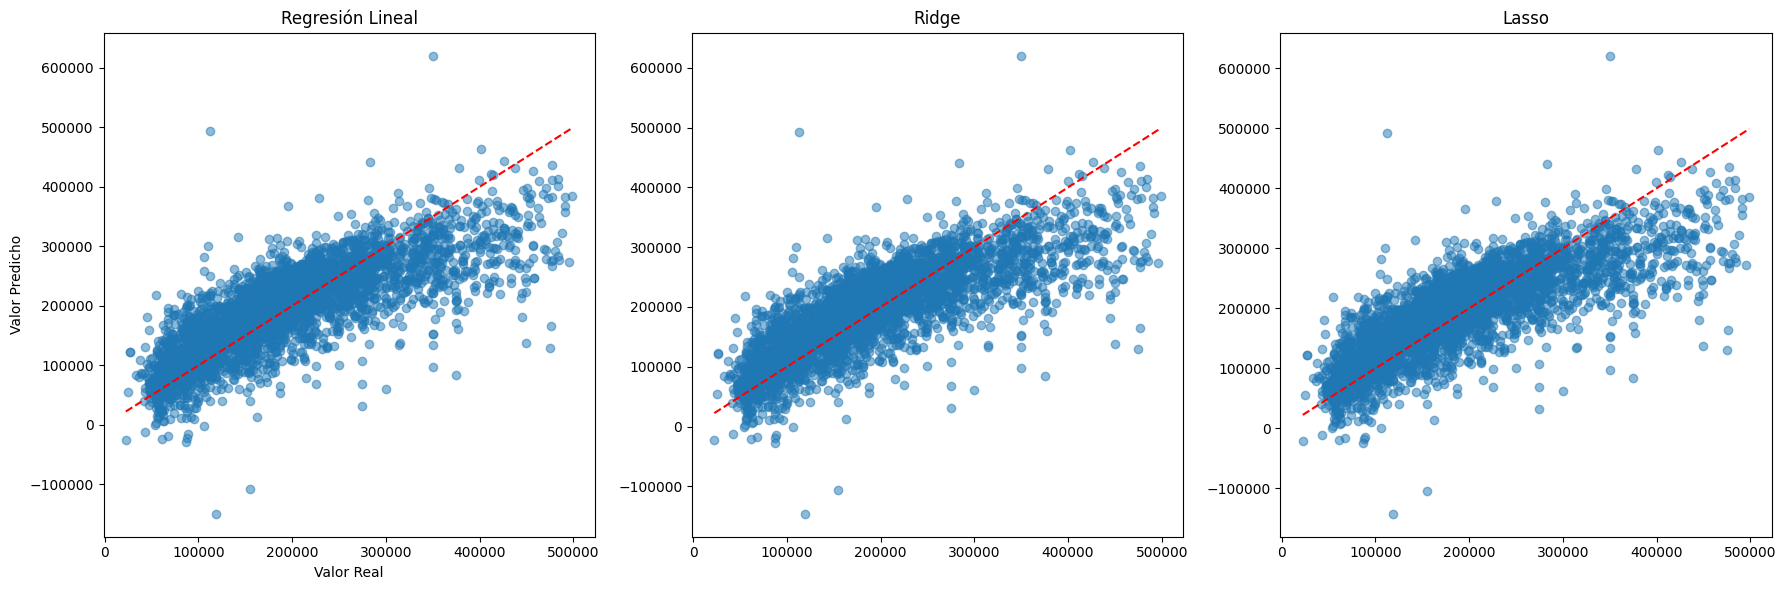

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))
# Linear
ax[0].scatter(y_test, y_test_pred_linear, alpha=0.5)
ax[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[0].set_title("Regresión Lineal")
ax[0].set_xlabel("Valor Real")
ax[0].set_ylabel("Valor Predicho")

# Ridge
ax[1].scatter(y_test, y_test_pred_ridge, alpha=0.5)
ax[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[1].set_title("Ridge")

# Lasso
ax[2].scatter(y_test, y_test_pred_lasso, alpha=0.5)
ax[2].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[2].set_title("Lasso")

plt.tight_layout()
plt.show()

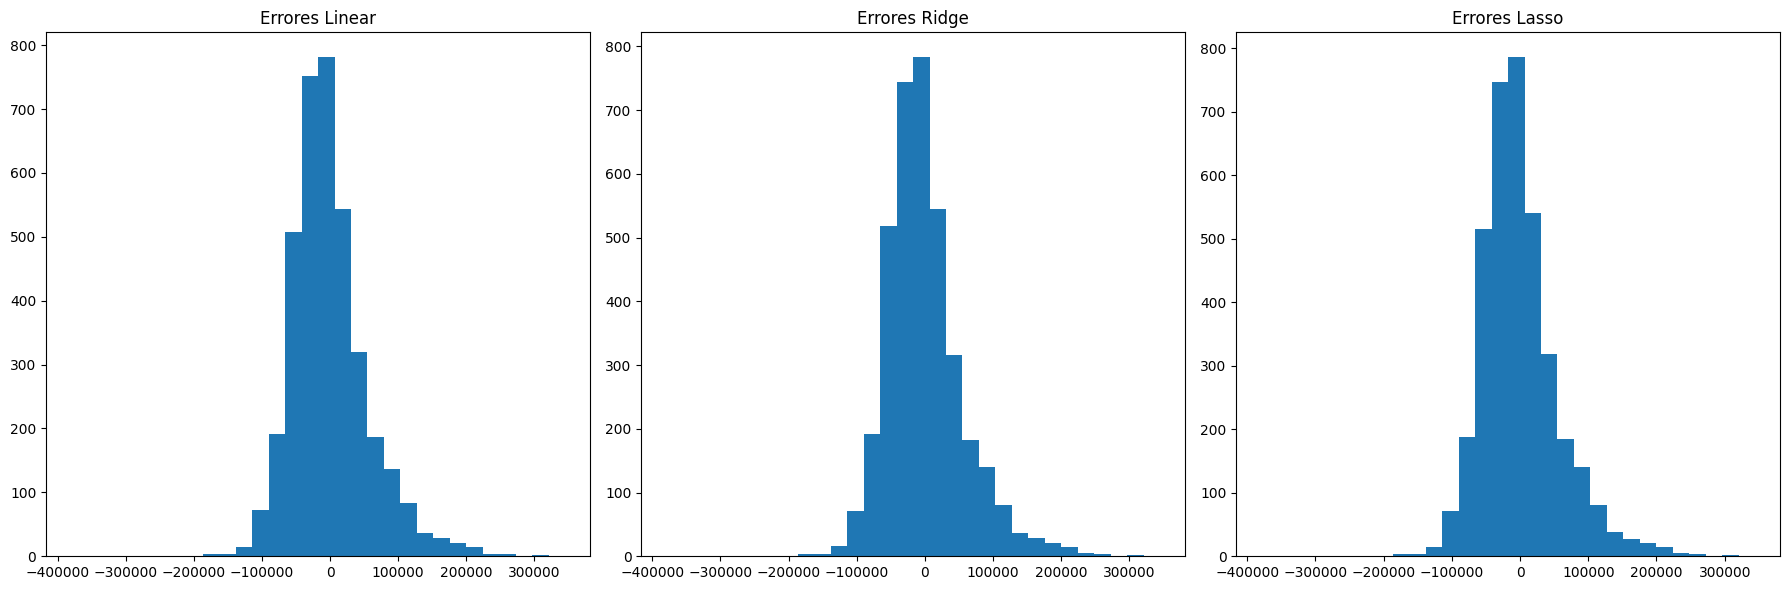

In [28]:
# Histogrma de error
fig, ax = plt.subplots(1,3, figsize=(18,6))

# Linear
ax[0].hist(
    y_test - y_test_pred_linear,
    bins=30
)
ax[0].set_title("Errores Linear")

# Ridge
ax[1].hist(
    y_test - y_test_pred_ridge,
    bins=30
)
ax[1].set_title("Errores Ridge")

# Lasso
ax[2].hist(
    y_test - y_test_pred_lasso,
    bins=30
)
ax[2].set_title("Errores Lasso")

plt.tight_layout()
plt.show()

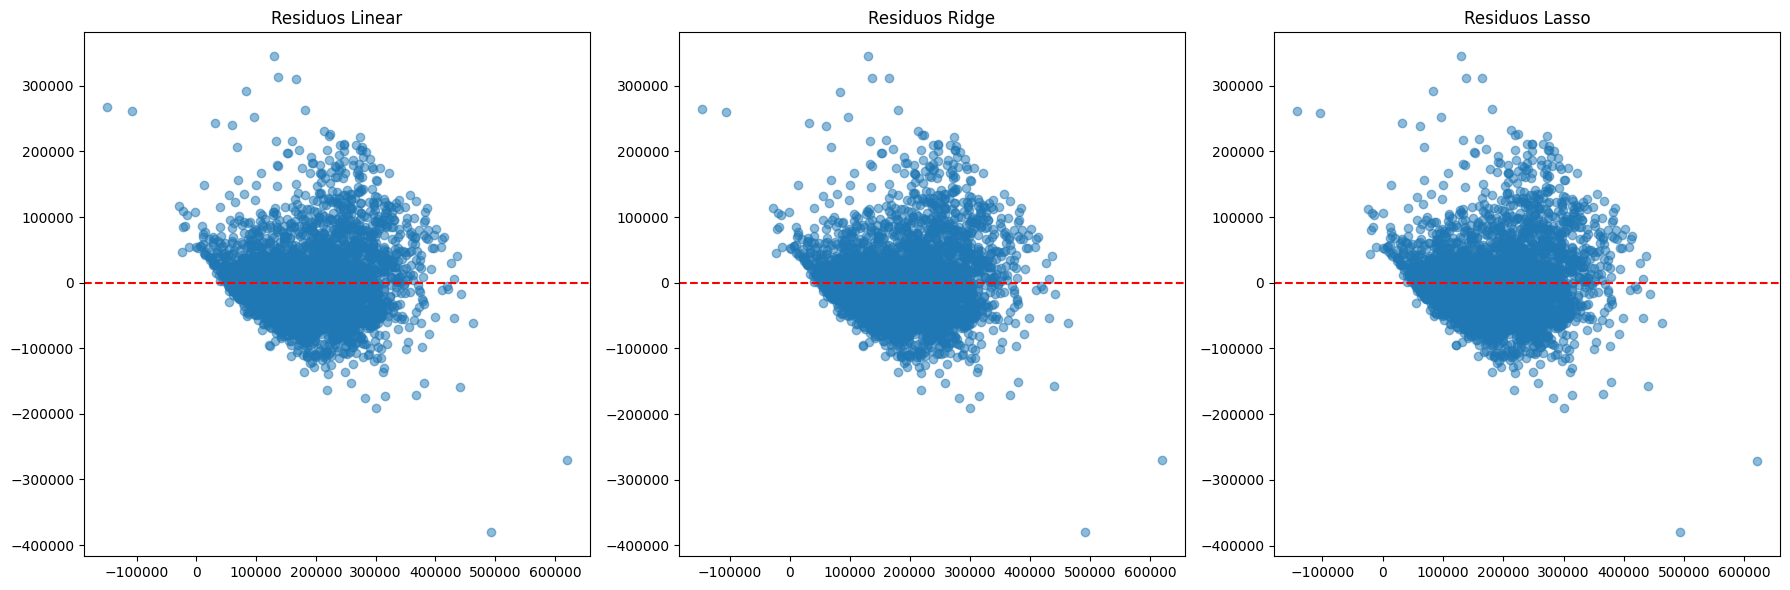

In [29]:
fig, ax = plt.subplots(1,3, figsize=(18,6))

# Linear
res_linear = y_test - y_test_pred_linear

ax[0].scatter(
    y_test_pred_linear,
    res_linear,
    alpha=0.5
)

ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title("Residuos Linear")

# Ridge
res_ridge = y_test - y_test_pred_ridge

ax[1].scatter(
    y_test_pred_ridge,
    res_ridge,
    alpha=0.5
)

ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title("Residuos Ridge")

# Lasso
res_lasso = y_test - y_test_pred_lasso

ax[2].scatter(
    y_test_pred_lasso,
    res_lasso,
    alpha=0.5
)

ax[2].axhline(0, color='red', linestyle='--')
ax[2].set_title("Residuos Lasso")

plt.tight_layout()
plt.show()

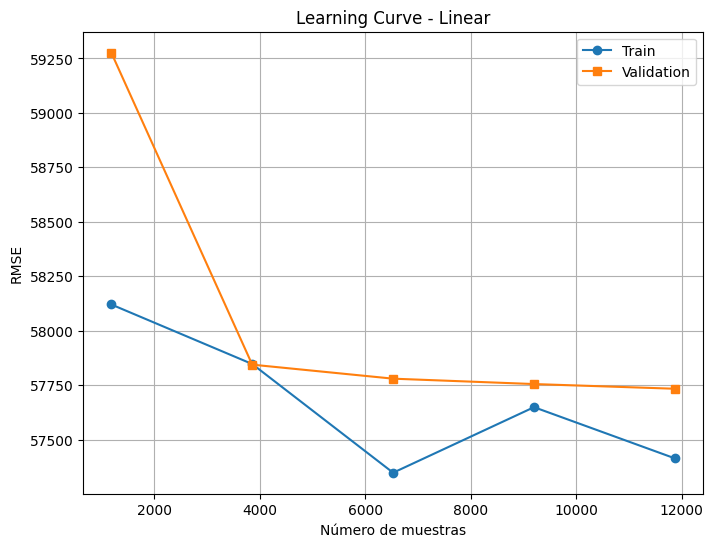

In [30]:
# Curva de aprendizaje regrsión standar
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    linear_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Linear")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

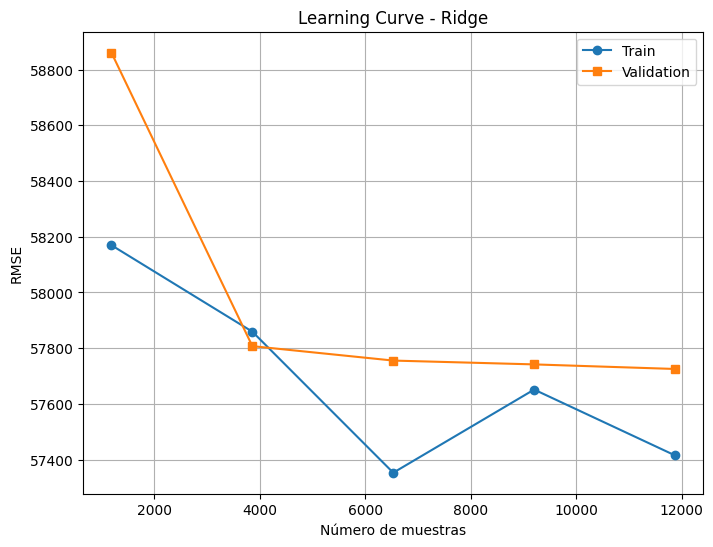

In [31]:
# Curva de aprendizaje regrsión ridge

train_sizes, train_scores, test_scores = learning_curve(
    ridge_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Ridge")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

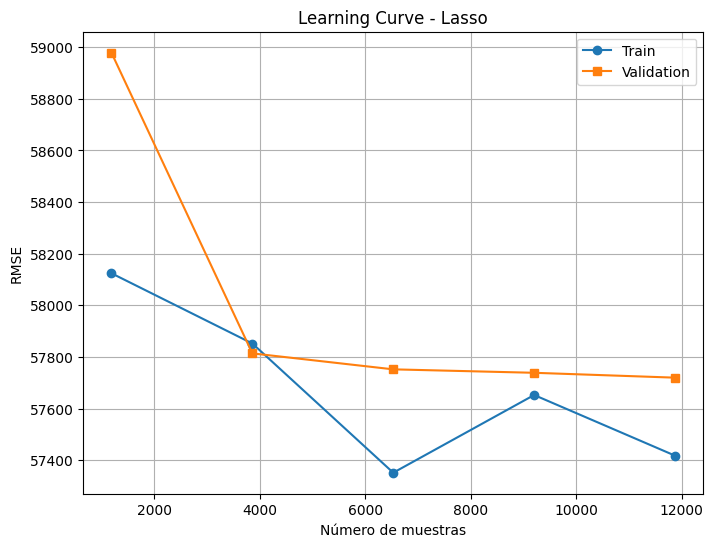

In [32]:
# Curva de aprendizaje regrsión lasso
train_sizes, train_scores, test_scores = learning_curve(
    lasso_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    -train_scores.mean(axis=1),
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    -test_scores.mean(axis=1),
    marker='s',
    label='Validation'
)

plt.title("Learning Curve - Lasso")
plt.xlabel("Número de muestras")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

### Conclusión
* **Diagnóstico de Sobreajuste (Overfitting):** El Error Cuadrático Medio (RMSE) en los conjuntos de entrenamiento y prueba es sumamente similar para ambos modelos. Esto indica que la regularización aplicada es efectiva y que los modelos generalizan correctamente sin memorizar el ruido de entrenamiento.
* **Comportamiento del Modelo Lasso (L1):** A pesar del uso de regularización L1 (con α=50), el modelo Lasso no ha reducido a cero ningún coeficiente. Esto sugiere que, a este nivel de penalización, todas las características de entrada conservan relevancia predictiva y no hay redundancia crítica.
* **Comparativa de Modelos:** El modelo Ridge (L2) presenta un rendimiento marginalmente superior en el conjunto de prueba, lo que indica que una penalización suave distribuida sobre todas las variables (L2) es más adecuada para este conjunto de datos que la selección estricta de variables (L1).

### Compración de los modelos

In [33]:
comparacion = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso'],
    'RMSE Train': [
        rmse_train_linear,
        rmse_train_ridge,
        rmse_train_lasso
    ],
    'RMSE Test': [
        rmse_test_linear,
        rmse_test_ridge,
        rmse_test_lasso
    ],
    'MAE Train': [
        mae_train_linear,
        mae_train_ridge,
        mae_train_lasso
    ],
    'MAE Test': [
        mae_test_linear,
        mae_test_ridge,
        mae_test_lasso
    ]
})

comparacion

,Modelo,RMSE Train,RMSE Test,MAE Train,MAE Test
0,Linear,57442.477422,57372.241368,41989.942583,42288.288106
1,Ridge,57443.482599,57365.555456,41991.324577,42285.944564
2,Lasso,57446.230791,57363.298868,41990.581761,42287.080215


### Deber para terminar el pippeline guardar y cargar el modelo RIDGE e ingresar nuevos valores por teclado y predecir el precio de una vivienda.

In [34]:
# Importar la librería para serialización de modelos
import joblib

# 1. Guardar el modelo Ridge y el escalador
# Asegúrate de que 'modelo_ridge' y 'scaler' sean los nombres exactos de tus variables
joblib.dump(ridge_model, 'modelo_ridge.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Modelo Ridge y escalador guardados exitosamente.\n")

# 2. Cargar el modelo y el escalador
modelo_cargado = joblib.load('modelo_ridge.pkl')
scaler_cargado = joblib.load('scaler.pkl')
print("Modelo Ridge y escalador cargados y listos para uso.\n")

# 3. Ingresar nuevos valores por teclado
print("Ingreso de Datos de la Vivienda")
nuevos_datos = {}

# Iterar sobre TODAS las columnas usadas en el entrenamiento (X)
for col in X.columns:
    while True:
        try:
            # Solicitar el valor correspondiente a la columna actual
            valor = float(input(f"Ingrese el valor numérico para '{col}': "))
            nuevos_datos[col] = [valor]
            break
        except ValueError:
            print("Error: Entrada inválida. Por favor, ingrese un número.")

# Convertir las entradas a DataFrame
df_nuevo = pd.DataFrame(nuevos_datos)

# 4. Preprocesar y Predecir
# Estandarizar usando el scaler cargado
df_nuevo_scaled = scaler_cargado.transform(df_nuevo)

# Realizar la predicción
prediccion = modelo_cargado.predict(df_nuevo_scaled)

# Imprimir resultado final
print(f"\nEl precio estimado de la vivienda es: ${prediccion[0]:,.2f}")

Modelo Ridge y escalador guardados exitosamente.

Modelo Ridge y escalador cargados y listos para uso.

Ingreso de Datos de la Vivienda


Ingrese el valor numérico para 'longitude':  -122.23
Ingrese el valor numérico para 'latitude':  37.88
Ingrese el valor numérico para 'housing_median_age':  41.0
Ingrese el valor numérico para 'total_rooms':  6.98
Ingrese el valor numérico para 'total_bedrooms':  1.02
Ingrese el valor numérico para 'population':  322.0
Ingrese el valor numérico para 'households':  210
Ingrese el valor numérico para 'median_income':  8.32
Ingrese el valor numérico para 'dist_to_LA':  5.53
Ingrese el valor numérico para 'dist_to_SF':  0.22
Ingrese el valor numérico para 'bedrooms_per_room':  5
Ingrese el valor numérico para 'pop_per_household':  20
Ingrese el valor numérico para 'ocean_proximity_INLAND':  1
Ingrese el valor numérico para 'ocean_proximity_ISLAND':  0
Ingrese el valor numérico para 'ocean_proximity_NEAR BAY':  1
Ingrese el valor numérico para 'ocean_proximity_NEAR OCEAN':  1



El precio estimado de la vivienda es: $1,342,482.73


### Conclusiones

Tras evaluar el rendimiento de los algoritmos aplicados para la estimación de precios de viviendas, se concluye que el modelo de regresión Ridge es la opción definitiva para su implementación.

**Justificación Técnica (Comparativa de Error Absoluto Medio - MAE Test)** <br>
La decisión se fundamenta estrictamente en las métricas de evaluación sobre datos no vistos, donde Ridge demostró la mayor precisión:

Modelo Ridge (Seleccionado): ✅ 42285.94

Modelo Lasso: ⚠️ 42287.08

Modelo Lineal: ⚠️ 42288.28

**Impacto Práctico y Financiero**

**Protección del Capital:** En el sector inmobiliario, la precisión es dinero. Al garantizar el margen de error más bajo posible con Ridge, se reduce significativamente el riesgo de subvalorar propiedades (pérdida directa de dinero) o sobrevalorarlas (estancamiento en el mercado).

**Escalabilidad Rentable:** Aunque la diferencia numérica entre los modelos parece estrecha para una sola vivienda, al multiplicar este comportamiento por cientos o miles de predicciones en un entorno real, la reducción del error acumulado que ofrece Ridge se traduce en un ahorro sustancial de recursos financieros.

**Robustez Analítica:** Matemáticamente, Ridge aplica una penalización (regularización L2) que controla la inflación de los coeficientes sin eliminar variables predictoras. Esto entrega un modelo más estable frente a la multicolinealidad, aprovechando toda la información del dataset original de manera segura.